In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier

In [21]:
train = pd.read_csv('data/clean/train_clean.csv')
test = pd.read_csv('data/clean/test_clean.csv')

In [22]:
X_train = train.drop("income", axis=1)
y_train = train["income"].str.strip().map({"<=50K": 0, ">50K": 1})

X_test = test.drop("income", axis=1)
y_test = test["income"].str.strip().map({"<=50K": 0, ">50K": 1})

In [23]:
X_train["gender"] = X_train["gender"].map({"Female": 0, "Male": 1})
X_test["gender"] = X_test["gender"].map({"Female": 0, "Male": 1})

In [24]:
cat_cols = ["workclass", "marital-status", "occupation", "relationship", "race", "native-country"]

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)

# Alineamos dataframes
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [25]:
# Hecho pro IA
# Limpieza de nombres de columnas (Evita que LightGBM dé warnings por caracteres raros)
X_train_encoded.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_train_encoded.columns]
X_test_encoded.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_test_encoded.columns]

In [26]:
print("Columnas en Train y Test después de get_dummies:", X_train_encoded.shape[1])

Columnas en Train y Test después de get_dummies: 43


In [27]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

    # Metricas
    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }
    
    return resultados

### Random Forest

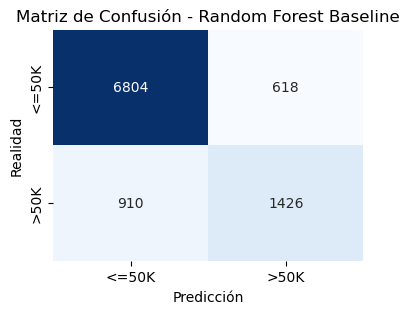

{'Modelo': 'Random Forest Baseline',
 'Accuracy': 0.8434105349456856,
 'Precision': 0.6976516634050881,
 'Recall': 0.610445205479452,
 'F1': 0.6511415525114155,
 'ROC_AUC': 0.8925862358943976}

In [28]:
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train_encoded, y_train)

resultado_rf_baseline = evaluar_modelo("Random Forest Baseline", rf_baseline, X_test_encoded, y_test)

resultado_rf_baseline

In [29]:
# Validacion cruzada
cv_rf_baseline = cross_val_score(
    rf_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1", 
    n_jobs=-1
)

print("F1 medio CV:", cv_rf_baseline.mean())
print("Desviación:", cv_rf_baseline.std())

F1 medio CV: 0.6643314844390259
Desviación: 0.0031944330301258896


In [30]:
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(rf_search.best_params_)

Mejores parámetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


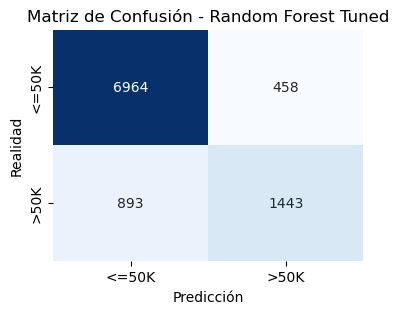

{'Modelo': 'Random Forest Tuned',
 'Accuracy': 0.8615494978479197,
 'Precision': 0.7590741714886902,
 'Recall': 0.617722602739726,
 'F1': 0.681142317677602,
 'ROC_AUC': 0.9158646325898937}

In [31]:
resultado_rf_tuned = evaluar_modelo(
    "Random Forest Tuned",
    rf_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_rf_tuned

### LightGBM

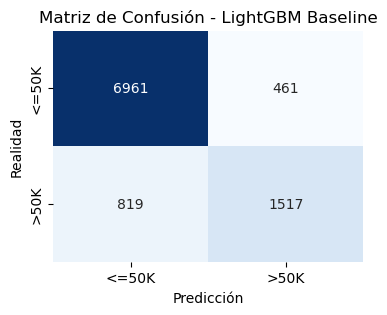

{'Modelo': 'LightGBM Baseline',
 'Accuracy': 0.8688255790120927,
 'Precision': 0.7669362992922144,
 'Recall': 0.6494006849315068,
 'F1': 0.703291608715809,
 'ROC_AUC': 0.9252041724805558}

In [32]:
lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)

lgbm_baseline.fit(X_train_encoded, y_train)

resultado_lgbm_baseline = evaluar_modelo(
    "LightGBM Baseline",
    lgbm_baseline,
    X_test_encoded,
    y_test
)

resultado_lgbm_baseline

In [33]:
cv_lgbm_baseline = cross_val_score(
    lgbm_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1", 
    n_jobs=-1
)

print("F1 medio CV:", cv_lgbm_baseline.mean())
print("Desviación:", cv_lgbm_baseline.std())

F1 medio CV: 0.7119610536295536
Desviación: 0.0026025889717588685


In [34]:
param_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_lgbm,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(lgbm_search.best_params_)

Mejores parámetros:
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


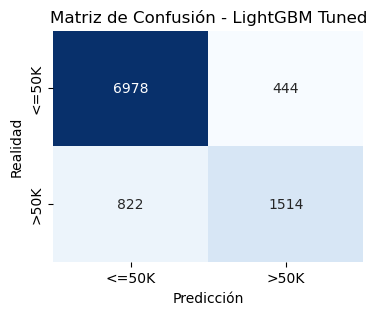

{'Modelo': 'LightGBM Tuned',
 'Accuracy': 0.8702602992416478,
 'Precision': 0.7732379979570991,
 'Recall': 0.6481164383561644,
 'F1': 0.7051700046576619,
 'ROC_AUC': 0.925813419609602}

In [35]:
resultado_lgbm_tuned = evaluar_modelo(
    "LightGBM Tuned",
    lgbm_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_lgbm_tuned

In [36]:
resultados = pd.DataFrame([
    resultado_rf_baseline,
    resultado_rf_tuned,
    resultado_lgbm_baseline,
    resultado_lgbm_tuned
])

resultados.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
3,LightGBM Tuned,0.870260,0.773238,0.648116,0.705170,0.925813
2,LightGBM Baseline,0.868826,0.766936,0.649401,0.703292,0.925204
1,Random Forest Tuned,0.861549,0.759074,0.617723,0.681142,0.915865
0,Random Forest Baseline,0.843411,0.697652,0.610445,0.651142,0.892586


### Conclusiones

Hemos evaluado las 4 variantes de los modelos, y hemos llegado a la conclusion de que el LightGBM Tuned es el mejor para solucionar este problema. Esto se ve en que tiene un Accuracy de 0,8703, un F1-score de 0,7052 y un ROC-AUC de 0,9258. El valor de ROC-AUC confirma que tiene muy buena capacidad analitica para poder serar a los ciudadanos con ingresos de mas de 50K a los que tienen menos. 


El hiperparametro del RandomizedSearchCV maximiza los resultados. En el Random Forest se nota en que el F1-score en la baseline es de 0,6511 y con los hiperparametros llega a 0,6811, esto significa que corrige el sobreajuste. Y en el LightGBM, no hay un cambio excesivo, pero esto ayuda a mejorar las metricas.

Estos resultado nos dicen que los modelos boosting (LightGBM) superan a los modelos bagging (Random Forest) en este problema. El LightGBM se adapta mejor a la complejidad y naturaleza de los datos.

La variable objetivo (income) estaba muy desbalanceada, se priorizo Precision y Recall a traves del F1-score. Asi conseguimos que LightGBM destaque por conseguir ese balance. Ademas la validacion cruzada afirma que los resultados son fiables y capaces de actualizarse a los nuevos datos. 

No tenemos overfitting, porque los resultados son bastante cercanos entre ellos, asi que nuestro modelo no se ha aprendido los datos de entrenamiento de memoria.